# Л2 — Сегментація й пошук закономірностей

Коли дані зібрано й очищено, з них починають видобувати знання. Універсального порядку тут немає: метод обирають під питання, на яке шукають відповідь.

Ноутбук нижче показує кілька поширених методів на одних даних і пастки, через які висновок буває хибним. Він не охоплює всіх методів (є, наприклад, DBSCAN чи змішані гаусові моделі), а приклади в ньому часом спрощені. Проте він дасть розуміння, що кожен метод показує і як його прочитати. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Feature Engineering](https://www.kaggle.com/learn/feature-engineering) з уроками про k-середні й головні компоненти.

| Питання | Метод | Кроки |
|---|---|---|
| На які групи діляться абоненти? | кластеризація: k-середні, метод Варда | 2, 4–7 |
| Які показники змінюються разом? | головні компоненти (PCA) | 3 |
| Як наочно показати, хто на кого схожий? | карта Кохонена | 8 |
| Які події трапляються разом? | асоціативні правила | 9 |
| Чи не обманює простий висновок? | перевірка пасток | 10 |

Спільні правила для всіх методів:

- методам на відстанях (k-середні, Вард, Кохонен) потрібен однаковий масштаб ознак, інакше ознака з великими числами переважить решту;
- кількість кластерів обирають і за метриками, і за тим, чи можна кластер пояснити;
- результат одного методу варто перевірити іншим;
- зв'язок у даних ще не означає причину: його може створювати третій чинник, а в частині даних він може бути протилежним.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця пасток — у `README.md`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from minisom import MiniSom
from mlxtend.frequent_patterns import apriori, association_rules

## 1. Завантаження даних

Дані цієї роботи вже чисті, тож досить переконатися, що файли прочиталися правильно, і подивитися, що всередині. Можуть допомогти `df.head()`, `df.shape` і `df.dtypes`.

In [2]:
customers = pd.read_parquet("data/customers.parquet")
events = pd.read_csv("data/events.csv", parse_dates=["event_ts"])

print(customers.shape, events.shape)
customers.head()

(2000, 15) (4079, 3)


,abonent_id,avg_daily_kwh,night_share,seasonality,weekend_ratio,stability,annual_charge_uah,avg_price_uah_kwh,voltage_dev_mean,loss_index_mean,tariff,meter_type,district,connection_year,churned
0,AB10001,19.242,0.3621,1.6752,0.9320,0.6877,24847.78,3.538,2.5756,5.0420,dual_zone,IND_1985,south,2009,0
1,AB10002,24.980,0.1233,1.2283,0.8598,0.7654,62456.93,6.850,5.5486,6.8498,business,SMART_B,west,1994,1
2,AB10003,8.115,0.1888,1.5943,1.0462,0.7135,11587.32,3.912,4.1090,9.7036,dual_zone,SMART_A,south,2020,0
3,AB10004,10.477,0.1154,1.0614,0.7261,0.8104,16519.68,4.320,5.5457,14.1345,single,IND_1985,north,1993,1
4,AB10005,23.444,0.1237,1.2613,0.6873,0.7615,58616.14,6.850,7.6942,24.4307,business,IND_1985,west,1980,0


## 2. Ознаки для сегментації

Кластеризація спирається на просторову близькість: кожен абонент — точка в просторі ознак, і схожі абоненти лежать поруч. Відстань рахується по всіх ознаках разом, тож ознака з великими числами переважить решту. Обсяг споживання в різних абонентів різниться в сотні разів, тому його спершу логарифмують, а потім усі ознаки стандартизують: середнє 0, стандартне відхилення 1. Грошей і договору серед ознак немає: сегмент описує, як абонент споживає.

Візьміть із `customers` колонки `features`, замініть `avg_daily_kwh` її натуральним логарифмом і стандартизуйте всі колонки. Результат назвіть `X`. Самі `customers` не змінюйте: у кроках 3 і 7 потрібні вихідні значення. Можуть допомогти `np.log` і `StandardScaler().fit_transform`.

In [3]:
features = ["avg_daily_kwh", "night_share", "seasonality", "weekend_ratio", "stability"]

features_log = customers[features].copy()
features_log["avg_daily_kwh"] = np.log(features_log["avg_daily_kwh"])
X = StandardScaler().fit_transform(features_log)

print(X.shape)
print("середні:", X.mean(axis=0).round(3))
print("відхилення:", X.std(axis=0).round(3))

(2000, 5)
середні: [ 0. -0. -0.  0. -0.]
відхилення: [1. 1. 1. 1. 1.]


## 3. Головні компоненти (PCA)

PCA повертає осі так, щоб перша головна компонента (principal component) йшла вздовж найбільшого розкиду даних, друга — вздовж найбільшого з решти, і так далі. Кожна компонента — лінійна комбінація вихідних показників. Найчастіше PCA використовують для зменшення розмірності: стиснути багато пов'язаних показників до кількох компонент перед моделлю чи для графіка. Але за нею можна й побачити, які показники змінюються разом, як у факторному аналізі. Тут саме це: погляд на 9 числових показників абонентів (усі числові колонки, крім `connection_year` і `churned`). На сегменти він не впливає.

Як читати результат:

- **eigenvalue** (власне значення) — скільки розкиду пояснює компонента в «одиницях одного показника»: сума eigenvalues ≈ кількість показників. Критерій Кайзера лишає компоненти з eigenvalue більше 1: кожна з них пояснює більше, ніж один показник;
- **loadings** (факторні навантаження) — кореляція показника з компонентою, від −1 до 1. Показники з великим за модулем loading (приблизно від 0.5) і однаковим знаком змінюються разом, з протилежним — у різні боки. Знак самої компоненти умовний: якщо перевернути всі знаки, зміст той самий;
- компоненту називають за її сильними показниками.

Приклад на інших даних — 5 показників 1000 людей. Eigenvalues перших двох компонент — 2.55 і 1.83, третьої — 0.25, тож за Кайзером лишаються дві, і разом вони пояснюють 88% розкиду.

| Показник | PC1 | PC2 |
|---|---|---|
| зріст | 0.92 | −0.12 |
| вага | 0.92 | 0.00 |
| розмір взуття | 0.92 | −0.10 |
| кроків за день | −0.11 | −0.95 |
| час бігу на 1 км | 0.10 | 0.95 |

У PC1 великі й однакові за знаком loadings мають зріст, вага й розмір взуття, решта біля нуля — це «розмір тіла». У PC2 сильні лише кроки й час бігу, і знаки в них протилежні: хто більше ходить, той швидше біжить. Це «активність», а великі значення PC2 тут означають малоактивних людей, бо знак компоненти умовний.

Збережений розкид — ще не збережена користь: для прогнозу може знадобитися саме компонента з малим eigenvalue, і перевірити це можна лише моделлю з цільовою колонкою.

1. Стандартизуйте 9 колонок без логарифма й застосуйте `PCA()`. `X` із кроку 2 не перезаписуйте, він потрібен далі.
2. Виведіть eigenvalues (`explained_variance_`), explained variance ratio кожної компоненти (`explained_variance_ratio_`) і накопичену частку.
3. Виведіть кількість компонент з eigenvalue більше 1.
4. Виведіть таблицю loadings перших двох компонент.
5. Назвіть першу компоненту за її сильними показниками одним реченням — це відповідь для питання 2 звіту.

In [4]:
numeric = ["avg_daily_kwh", "night_share", "seasonality", "weekend_ratio", "stability",
           "annual_charge_uah", "avg_price_uah_kwh", "voltage_dev_mean", "loss_index_mean"]
numeric_scaled = StandardScaler().fit_transform(customers[numeric])
pca = PCA().fit(numeric_scaled)

pca_table = pd.DataFrame({
    "eigenvalue": pca.explained_variance_,
    "частка": pca.explained_variance_ratio_,
    "накопичена": pca.explained_variance_ratio_.cumsum(),
}, index=[f"PC{i + 1}" for i in range(len(numeric))])
print(pca_table.round(3), "\n")
print("компонент з eigenvalue > 1:", (pca.explained_variance_ > 1).sum(), "\n")

loadings = pd.DataFrame(pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2]),
                        index=numeric, columns=["PC1", "PC2"])
loadings.round(2)

     eigenvalue  частка  накопичена
PC1       3.707   0.412       0.412
PC2       1.426   0.158       0.570
PC3       1.289   0.143       0.713
PC4       0.870   0.097       0.810
PC5       0.624   0.069       0.879
PC6       0.570   0.063       0.942
PC7       0.349   0.039       0.981
PC8       0.144   0.016       0.997
PC9       0.025   0.003       1.000 

компонент з eigenvalue > 1: 3 



,PC1,PC2
avg_daily_kwh,-0.68,-0.39
night_share,0.61,-0.06
seasonality,0.76,-0.32
weekend_ratio,0.84,-0.05
stability,-0.71,0.32
annual_charge_uah,-0.79,-0.35
avg_price_uah_kwh,-0.67,-0.03
voltage_dev_mean,0.01,0.68
loss_index_mean,-0.02,0.69


## 4. Кількість кластерів

k-середні ділять абонентів на k кластерів. Центр кластера (центроїд) — середнє всіх його точок, тобто усереднений представник: за ним описують увесь кластер. Алгоритм відносить кожного абонента до найближчого центру й перераховує центри, доки абоненти не перестануть переходити між кластерами. Коли кластер вдається описати як тип абонентів, його називають сегментом.

Інерція — сума квадратів відстаней від абонентів до центрів їхніх кластерів. Вона спадає з кожним новим k, тож шукають «лікоть»: місце, де спад сповільнюється. Силует, від −1 до 1, показує, наскільки абонент ближчий до свого кластера, ніж до сусіднього. Він часто найбільший при малих k, бо грубий поділ чіткіший за детальний. Але два кластери нічого не кажуть про типи споживачів, тому k обирають від 3 до 6.

Для k від 2 до 8 побудуйте k-середні на `X`, виведіть таблицю «k, інерція (`inertia_`), силует (`silhouette_score`)» і два графіки: інерція від k і силует від k.

   k   інерція  силует
0  2  5430.188   0.473
1  3  4062.656   0.335
2  4  3103.011   0.369
3  5  2735.481   0.325
4  6  2516.247   0.314
5  7  2341.810   0.238
6  8  2166.955   0.232


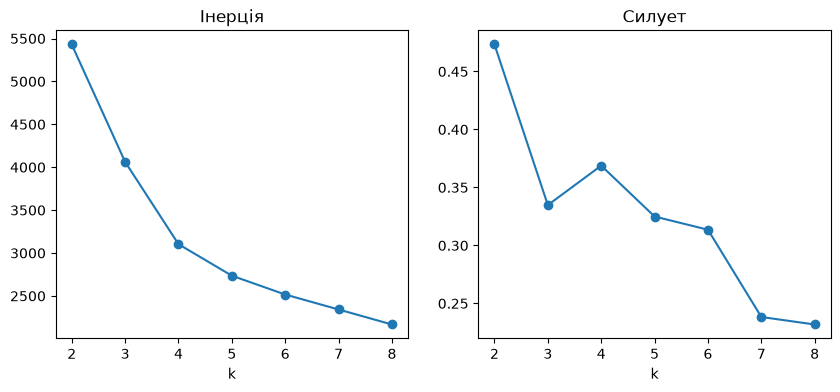

In [5]:
rows = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    rows.append({"k": k, "інерція": model.inertia_, "силует": silhouette_score(X, model.labels_)})
k_table = pd.DataFrame(rows)
print(k_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(k_table["k"], k_table["інерція"], marker="o")
axes[0].set_title("Інерція")
axes[0].set_xlabel("k")
axes[1].plot(k_table["k"], k_table["силует"], marker="o")
axes[1].set_title("Силует")
axes[1].set_xlabel("k")
plt.show()

## 5. Ієрархічна кластеризація

Метод Варда починає з окремих абонентів і щоразу об'єднує два кластери, від злиття яких сума квадратів відстаней усередині кластерів росте найменше. Дендрограма показує всю історію об'єднань: довгі вертикальні лінії вгорі означають, що злито дуже різні кластери, і різати варто саме там.

| | k-середні | Метод Варда |
|---|---|---|
| кількість кластерів | задають наперед | не потрібна: дендрограма показує поділ на будь-яке k |
| що дає | центри кластерів; нового абонента відносять до найближчого центру | ієрархію: видно, які кластери є частинами більших |
| слабке місце | може застрягти в невдалому поділі, тому запускають кілька разів (`n_init`) | невдале раннє об'єднання не виправляється |
| великі дані | швидкий і на мільйонах рядків | рахує відстані між усіма парами, тому повільний |

Тут Вард допомагає обрати k і перевірити, чи поділ стійкий, а сегменти для `segments.csv` беруть із k-середніх: у них є центри, за якими описують сегменти й відносять нових абонентів.

1. Побудуйте `Z = linkage(X, "ward")` і дендрограму верхніх 30 об'єднань: `dendrogram(Z, truncate_mode="lastp", p=30)`.
2. Для k від 3 до 6 виведіть довжину розрізу на k кластерів. `Z[:, 2]` — висоти об'єднань, і розріз на k кластерів лежить між k-м і (k−1)-м об'єднанням з кінця.
3. Дендрограма підказує k із найбільшою довжиною розрізу: такий розріз перетинає найдовші вертикальні лінії.

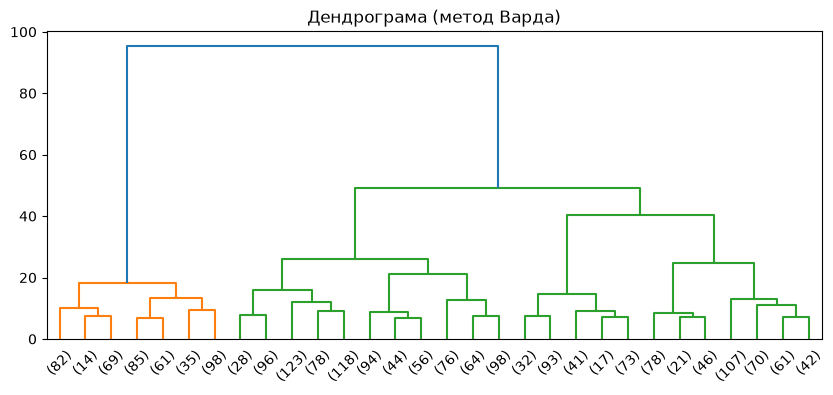

k = 3: довжина розрізу 8.69
k = 4: довжина розрізу 14.50
k = 5: довжина розрізу 1.12
k = 6: довжина розрізу 3.56


In [6]:
Z = linkage(X, "ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Дендрограма (метод Варда)")
plt.show()

for k in range(3, 7):
    cut = Z[-(k - 1), 2] - Z[-k, 2]
    print(f"k = {k}: довжина розрізу {cut:.2f}")

## 6. Порівняння двох поділів

Методи будують кластери по-різному (крок 5), тож поділи можуть різнитися. Якщо вони схожі, кластери відображають структуру самих даних, а не особливість одного методу.

Як порівняти два поділи:

- **таблиця спряженості** (contingency table, `pd.crosstab`): рядок — кластер k-середніх, стовпець — кластер Варда, у клітинці — скільки абонентів потрапили в обидва. Номери в двох методах не пов'язані: кластер 0 k-середніх може відповідати кластеру 3 Варда. Тому дивляться не на діагональ, а на те, чи в кожному рядку одна велика клітинка. Якщо великих дві, цей кластер Вард ділить між двома своїми;
- **ARI** (adjusted Rand index, `adjusted_rand_score`) — одне число: наскільки однаково два поділи розкладають абонентів «разом» чи «окремо», з поправкою на випадкові збіги. Від номерів кластерів не залежить. 1 — поділи однакові, близько 0 — збігаються не більше, ніж випадкові. Орієнтовно: від 0.9 — майже однакові, 0.65–0.9 — схожі, але частина абонентів переходить, нижче 0.65 — суттєво різні.

Приклад, 2000 абонентів, три кластери, ARI 0.78:

| | Вард 1 | Вард 2 | Вард 3 |
|---|---|---|---|
| k-середні 0 | 0 | 480 | 5 |
| k-середні 1 | 610 | 10 | 0 |
| k-середні 2 | 0 | 150 | 745 |

Кластери 0 і 1 k-середніх майже цілком збігаються з кластерами Варда 2 і 1. Кластер 2 здебільшого — кластер Варда 3, але 150 його абонентів Вард відніс до кластера 2: межу між цими двома кластерами методи проводять по-різному.

1. Оберіть k від 3 до 6, зважаючи на кроки 4 і 5. Якщо вони підказують різне, вибір за вами: у звіті напишіть, на що спиралися. Якщо в кроці 7 якийсь сегмент не вдасться описати одним реченням, можна повернутися й узяти інше k.
2. Побудуйте k-середні на `X` з тими самими параметрами, що в кроці 4, і назвіть мітки кластерів `labels`: це сегменти для `segments.csv`.
3. Розріжте дендрограму на k кластерів: `fcluster(Z, k, "maxclust")`, кластери нумеруються з 1.
4. Виведіть таблицю спряженості двох поділів і ARI.
5. Знайдіть кластери, які методи ділять по-різному, або переконайтеся, що поділи майже однакові, — це відповідь для питання 2 звіту.

In [7]:
k = 4

labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).labels_
ward_labels = fcluster(Z, k, "maxclust")

print(pd.crosstab(labels, ward_labels, rownames=["k-середні"], colnames=["Вард"]))
print("\nARI:", round(adjusted_rand_score(labels, ward_labels), 3))

Вард         1    2    3    4
k-середні                    
0            0   25  253   95
1          443    2    0    0
2            0  116    1  321
3            1  732    2    9

ARI: 0.727


## 7. Профіль сегментів

Сегмент корисний, коли його можна описати одним реченням, наприклад «нічна частка вдвічі більша, ніж у базі загалом». Середні ознак сегмента — це його центр у вихідних одиницях (крок 4), тож профіль порівнює центри сегментів із середнім усієї бази.

Виведіть таблицю: рядок на кожен сегмент із `labels` і рядок «уся база». Колонки — кількість абонентів, середні `features` у вихідних одиницях, частка `churned` і частка лічильників `IND_1985`. Можуть допомогти `customers.assign(segment=labels, ind_1985=customers["meter_type"] == "IND_1985")`, `groupby` і `pd.concat`.

In [8]:
profile_data = customers.assign(segment=labels, ind_1985=customers["meter_type"] == "IND_1985")
columns = features + ["churned", "ind_1985"]

by_segment = profile_data.groupby("segment")[columns].mean()
by_segment.insert(0, "абонентів", profile_data.groupby("segment").size())

whole_base = profile_data[columns].mean().to_frame("уся база").T
whole_base.insert(0, "абонентів", len(profile_data))

profile = pd.concat([by_segment, whole_base])
profile.round(3)

,абонентів,avg_daily_kwh,night_share,seasonality,weekend_ratio,stability,churned,ind_1985
0,373,20.206,0.469,1.568,1.032,0.719,0.190,0.142
1,445,44.363,0.126,1.185,0.642,0.763,0.328,0.216
2,438,25.628,0.297,1.916,1.079,0.652,0.148,0.126
3,744,12.505,0.227,1.486,1.069,0.703,0.204,0.103
уся база,2000,23.903,0.265,1.528,0.969,0.708,0.217,0.140


## 8. Карта Кохонена

Карта Кохонена — сітка нейронів. Для кожного абонента знаходять найближчий нейрон-переможець і підтягують до абонента і цей нейрон, і його сусідів у межах радіуса `sigma`. Так схожі абоненти потрапляють у сусідні вузли. Топографічна помилка — частка абонентів, у яких два найближчі нейрони не сусідні на сітці: що вона менша, то краще карта зберігає сусідство.

Радіус визначає, скільки сусідів навчаються разом із переможцем. Код нижче готовий: він навчає дві карти, з `sigma=1.5` і з `sigma=0.5`, виводить топографічну помилку обох і малює першу. На малюнку фон — відстані між сусідніми нейронами: що темніше, то далі сусіди один від одного, тож темні смуги — межі між групами. Точки — абоненти у своїх вузлах, колір — сегмент із кроку 6.

Запустіть і порівняйте топографічну помилку двох карт: яка краще зберігає сусідство і чому це пов'язано з радіусом, — це відповідь для питання 2 звіту. Подивіться також, чи лежать точки одного сегмента на карті поруч.

топографічна помилка: sigma = 1.5 — 0.156, sigma = 0.5 — 0.742


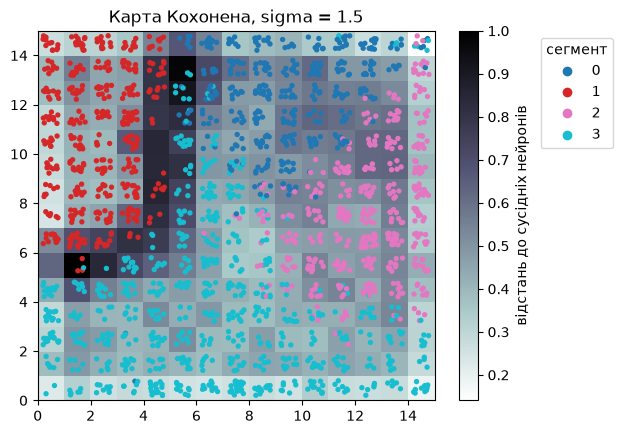

In [9]:
def train_som(sigma):
    som = MiniSom(15, 15, X.shape[1], sigma=sigma, learning_rate=0.5, random_seed=0)
    som.pca_weights_init(X)
    som.train(X, 20000, random_order=True)
    return som

som = train_som(1.5)
som_small = train_som(0.5)
print(f"топографічна помилка: sigma = 1.5 — {som.topographic_error(X):.3f}, sigma = 0.5 — {som_small.topographic_error(X):.3f}")

winners = np.array([som.winner(x) for x in X]) + 0.5
jitter = np.random.default_rng(0).uniform(-0.3, 0.3, size=winners.shape)
mesh = plt.pcolor(som.distance_map().T, cmap="bone_r")
plt.colorbar(mesh, label="відстань до сусідніх нейронів")
points = plt.scatter(*(winners + jitter).T, c=labels, s=8, cmap="tab10")
plt.legend(*points.legend_elements(), title="сегмент", loc="upper left", bbox_to_anchor=(1.25, 1))
plt.title("Карта Кохонена, sigma = 1.5")
plt.show()

## 9. Асоціативні правила

Правило «A → B» означає: у кого є A, у того часто є й B. Підтримка — частка абонентів, у яких є і A, і B. Достовірність — частка абонентів із B серед тих, у кого є A. Ліфт — у скільки разів достовірність більша за частку B у всій базі; ліфт 1 означає, що зв'язку немає.

Apriori відкидає набір, щойно його підтримка нижча за поріг, і вже не перевіряє ширших наборів із ним: ширший набір не може траплятися частіше за свою частину.

Код нижче вже будує таблицю «абонент × тип події» (подій `churn` у ній немає, замість них колонка `churned`) і знаходить правила з достовірністю від 0.3 для заданого порога підтримки.

1. Допишіть у `churn_rules` фільтр: лише правила, у яких наслідок рівно `churned` (`rules["consequents"] == frozenset({"churned"})`), відсортовані за ліфтом.
2. При підтримці 0.05 виведіть кількість цих правил і перші 5 із підтримкою, достовірністю й ліфтом.
3. При підтримці 0.10 виведіть, скільки правил лишилося.
4. Прочитайте найсильніше правило: у скільки разів частіше йдуть абоненти з цими подіями, ніж у середньому, і чому з вищим порогом правил менше, — це відповідь для питання 2 звіту.

In [10]:
no_churn = events[events["event_type"] != "churn"]
basket = pd.crosstab(no_churn["abonent_id"], no_churn["event_type"]) > 0  # True, якщо в абонента була хоч одна така подія
basket = basket.reindex(customers["abonent_id"], fill_value=False)  # абоненти без подій — рядок із False
basket["churned"] = customers["churned"].astype(bool).to_numpy()  # рядки йдуть у тому самому порядку, що в customers


def churn_rules(min_support):
    frequent = apriori(basket, min_support=min_support, use_colnames=True)  # набори подій, що трапляються не рідше за поріг
    rules = association_rules(frequent, num_itemsets=len(basket), metric="confidence", min_threshold=0.3)
    return rules[rules["consequents"] == frozenset({"churned"})].sort_values("lift", ascending=False)


rules_05 = churn_rules(0.05)
print("правил при підтримці 0.05:", len(rules_05))
print(rules_05[["antecedents", "support", "confidence", "lift"]].head().round(3))

rules_10 = churn_rules(0.10)
print("\nправил при підтримці 0.10:", len(rules_10))

правил при підтримці 0.05: 25
                                           antecedents  support  confidence  \
152     frozenset({complaint, contract_query, outage})    0.064       0.585   
249  frozenset({contract_query, outage, tariff_chan...    0.056       0.574   
172  frozenset({complaint, contract_query, payment_...    0.066       0.552   
184  frozenset({complaint, contract_query, tariff_c...    0.074       0.552   
217      frozenset({complaint, outage, tariff_change})    0.082       0.548   

      lift  
152  2.697  
249  2.643  
172  2.543  
184  2.543  
217  2.528  

правил при підтримці 0.10: 9


## 10. Пастки (T-1, T-2, T-3)

Простий висновок із даних буває хибним. Що означає кожна пастка, сказано в таблиці в `README.md`. Перевірте кожну й виведіть числа, які порівнюються з порогом:

- **T-1:** кореляцію `voltage_dev_mean` і `loss_index_mean` по всій базі й окремо в кожному `district`;
- **T-2:** середню `seasonality` в абонентів із лічильниками `IND_1985`, у решти й відношення першої до другої;
- **T-3:** кореляцію `avg_price_uah_kwh` і `churned` серед 600 абонентів (30%) із найбільшим `annual_charge_uah` і серед решти.

Можуть допомогти `corr`, `groupby("district")` і `nlargest`.

In [11]:
# T-1: прихований чинник
r_all = customers["voltage_dev_mean"].corr(customers["loss_index_mean"])
print(f"T-1: r по всій базі = {r_all:.3f}")
for district, group in customers.groupby("district"):
    print(f"     {district}: r = {group['voltage_dev_mean'].corr(group['loss_index_mean']):.3f}")

# T-2: технічна група
is_ind = customers["meter_type"] == "IND_1985"
season_ind = customers.loc[is_ind, "seasonality"].mean()
season_rest = customers.loc[~is_ind, "seasonality"].mean()
print(f"\nT-2: IND_1985 = {season_ind:.3f}, решта = {season_rest:.3f}, відношення = {season_ind / season_rest:.3f}")

# T-3: протилежний зв'язок у частині бази
top_ids = customers.nlargest(600, "annual_charge_uah").index
top_customers = customers.loc[top_ids]
other_customers = customers.drop(top_ids)
r_top = top_customers["avg_price_uah_kwh"].corr(top_customers["churned"])
r_other = other_customers["avg_price_uah_kwh"].corr(other_customers["churned"])
print(f"\nT-3: r серед 600 найбільших = {r_top:.3f}, серед решти = {r_other:.3f}")

T-1: r по всій базі = 0.377
     centre: r = 0.011
     north: r = 0.021
     south: r = -0.032
     west: r = 0.024

T-2: IND_1985 = 1.481, решта = 1.536, відношення = 0.964

T-3: r серед 600 найбільших = 0.275, серед решти = 0.184


## 11. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [12]:
x = np.asarray(X)
segments = pd.DataFrame({"abonent_id": customers["abonent_id"], "segment_id": labels})

assert x.shape == (2000, 5), "X має містити 2000 абонентів і 5 ознак із features"
assert np.allclose(x.mean(axis=0), 0) and np.allclose(x.std(axis=0), 1, atol=1e-3), "ознаки X не стандартизовано"
assert np.corrcoef(x[:, 0], np.log(customers["avg_daily_kwh"]))[0, 1] > 0.999, "перша колонка X — не логарифм avg_daily_kwh, або customers змінено чи пересортовано"
assert len(segments) == 2000 and segments["abonent_id"].is_unique, "має бути рядок на кожного з 2000 абонентів"
assert pd.api.types.is_integer_dtype(segments["segment_id"]), "segment_id мають бути цілі числа"
assert 3 <= segments["segment_id"].nunique() <= 6, "сегментів має бути від 3 до 6"

segments.to_csv("segments.csv", index=False)
print("усе гаразд:", segments["segment_id"].value_counts().sort_index().to_dict())

усе гаразд: {0: 373, 1: 445, 2: 438, 3: 744}
